#EV Fleet Demand Forecasting & Rebalancing Optimization System

PROBLEM : Operational Challenges: Some users have reported issues with finding working bikes in certain areas

In [ ]:
# ====================== IMPORTS ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('train.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

In [ ]:
# ====================== FEATURE ENGINEERING ======================
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['is_peak_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# Lag
df['lag_1'] = df['count'].shift(1)
df['lag_2'] = df['count'].shift(2)
df['lag_24'] = df['count'].shift(24)

# Rolling
df['rolling_mean_3'] = df['count'].shift(1).rolling(3).mean()
df['rolling_mean_24'] = df['count'].shift(1).rolling(24).mean()

df = df.dropna().reset_index(drop=True)

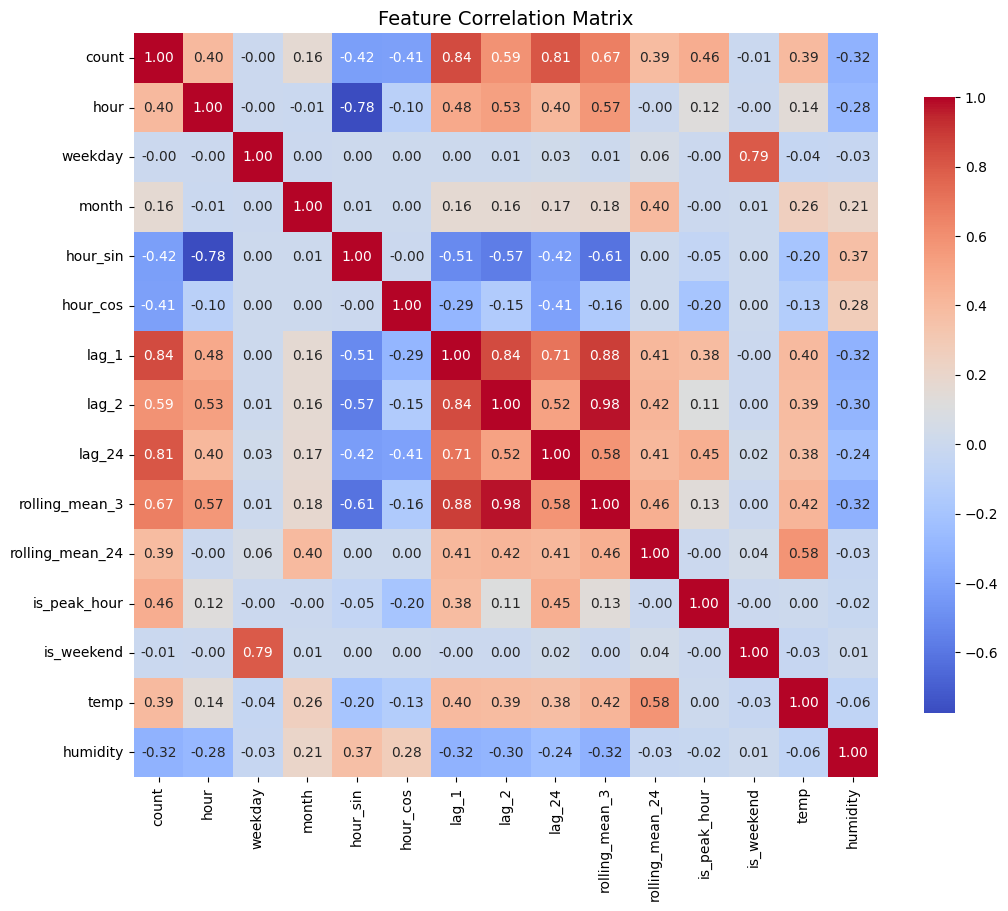

In [ ]:
# ====================== CORRELATION ANALYSIS ======================

# Select only relevant features
corr_features = [
    'count',
    'hour','weekday','month',
    'hour_sin','hour_cos',
    'lag_1','lag_2','lag_24',
    'rolling_mean_3','rolling_mean_24',
    'is_peak_hour','is_weekend',
    'temp','humidity'
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(12,10))
import seaborn as sns

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()

In [ ]:
# ====================== FEATURES ======================
features = [
    'hour','weekday','month',
    'hour_sin','hour_cos',
    'lag_1','lag_2','lag_24',
    'rolling_mean_3','rolling_mean_24',
    'is_peak_hour','is_weekend',
    'temp','humidity'
]

X = df[features]
y = df['count']

In [ ]:
# ====================== TIME SERIES CV ======================
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

mae_scores = []
rmse_scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb.fit(X_train, y_train)
    preds = xgb.predict(X_test)

    mae_scores.append(mean_absolute_error(y_test, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, preds)))

print("CV MAE:", round(np.mean(mae_scores),2))
print("CV RMSE:", round(np.mean(rmse_scores),2))

CV MAE: 35.16
CV RMSE: 56.12


In [ ]:
# ====================== FINAL TRAIN ======================
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train[features]
y_train = train['count']

X_test = test[features]
y_test = test['count']

xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

print("\nFinal MAE:", round(mean_absolute_error(y_test, preds),2))
print("Final RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)),2))


Final MAE: 32.1
Final RMSE: 52.01


In [ ]:
# ====================== FORECAST ======================
future_steps = 24
last_df = df.copy()
future_preds = []

for i in range(future_steps):
    last_row = last_df.iloc[-1:].copy()

    last_row['datetime'] += pd.Timedelta(hours=1)

    last_row['hour'] = last_row['datetime'].dt.hour
    last_row['day'] = last_row['datetime'].dt.day
    last_row['month'] = last_row['datetime'].dt.month
    last_row['weekday'] = last_row['datetime'].dt.weekday

    last_row['hour_sin'] = np.sin(2*np.pi*last_row['hour']/24)
    last_row['hour_cos'] = np.cos(2*np.pi*last_row['hour']/24)

    last_row['is_peak_hour'] = last_row['hour'].isin([7,8,9,17,18,19]).astype(int)
    last_row['is_weekend'] = last_row['weekday'].isin([5,6]).astype(int)

    last_row['lag_1'] = last_df['count'].iloc[-1]
    last_row['lag_2'] = last_df['count'].iloc[-2]
    last_row['lag_24'] = last_df['count'].iloc[-24]

    last_row['rolling_mean_3'] = last_df['count'].iloc[-3:].mean()
    last_row['rolling_mean_24'] = last_df['count'].iloc[-24:].mean()

    pred = xgb.predict(last_row[features])[0]
    pred = max(0, pred)

    future_preds.append(pred)

    last_row['count'] = pred
    last_df = pd.concat([last_df, last_row], ignore_index=True)

future_preds = pd.Series(future_preds).ewm(span=3).mean()

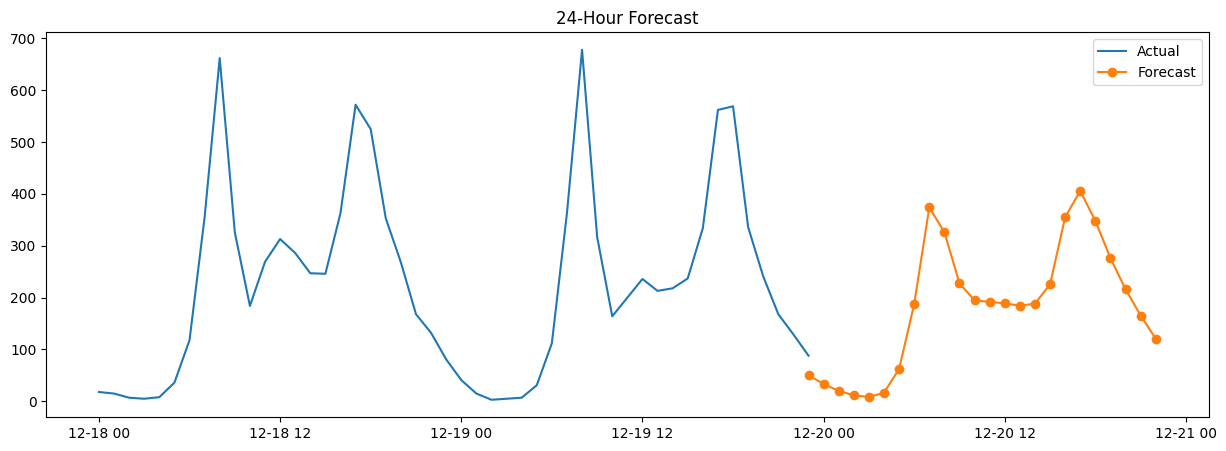

In [ ]:
# Plot
future_time = pd.date_range(df['datetime'].iloc[-1], periods=24, freq='H')

plt.figure(figsize=(15,5))
plt.plot(df['datetime'].iloc[-48:], df['count'].iloc[-48:], label='Actual')
plt.plot(future_time, future_preds, label='Forecast', marker='o')
plt.legend()
plt.title("24-Hour Forecast")
plt.show()

In [ ]:
# ====================== REALISTIC ZONES ======================
# Simulate geo-coordinates
np.random.seed(42)
df['lat'] = np.random.uniform(12.9, 13.1, len(df))
df['lon'] = np.random.uniform(77.5, 77.7, len(df))

kmeans = KMeans(n_clusters=5, random_state=42)
df['zone'] = kmeans.fit_predict(df[['lat','lon']])

In [ ]:
# ====================== ZONE DEMAND ======================
zone_demand = df.groupby('zone')['count'].mean().values

print("\nZone Demand:")
for i,d in enumerate(zone_demand):
    print(f"Zone {i}: {int(d)}")


Zone Demand:
Zone 0: 189
Zone 1: 192
Zone 2: 194
Zone 3: 194
Zone 4: 187


In [ ]:
# ====================== SURPLUS / DEFICIT ======================
high = np.percentile(zone_demand,75)
low = np.percentile(zone_demand,25)

surplus = [i for i,d in enumerate(zone_demand) if d < low]
deficit = [i for i,d in enumerate(zone_demand) if d > high]

print("\nSurplus Zones:", surplus)
print("Deficit Zones:", deficit)


Surplus Zones: [4]
Deficit Zones: [3]


In [ ]:

# ====================== REAL DISTANCE MATRIX ======================
zone_coords = df.groupby('zone')[['lat','lon']].mean().values

distance_matrix = cdist(zone_coords, zone_coords, metric='euclidean')

In [ ]:
# ====================== OPTIMIZATION ======================
cost_matrix = distance_matrix[np.ix_(surplus, deficit)]

row_ind, col_ind = linear_sum_assignment(cost_matrix)

print(" OPTIMAL BIKE MOVEMENT ---")
for r,c in zip(row_ind, col_ind):
    from_zone = surplus[r]
    to_zone = deficit[c]

    move = int(abs(zone_demand[to_zone] - zone_demand[from_zone]) * 0.5)

    print(f"Move {move} bikes: Zone {from_zone} → Zone {to_zone} | Cost: {round(cost_matrix[r][c],2)}")

 OPTIMAL BIKE MOVEMENT ---
Move 3 bikes: Zone 4 → Zone 3 | Cost: 0.07


In [ ]:
# ====================== BUSINESS INSIGHTS ======================
peak_hour = df.groupby('hour')['count'].mean().idxmax()
low_hour = df.groupby('hour')['count'].mean().idxmin()

print("\n--- BUSINESS DECISIONS ---")

print(f"Peak demand at {peak_hour}:00 → pre-position bikes 1–2 hours before")
print(f"Low demand at {low_hour}:00 → collect idle fleet")

print(f"\nRebalance Plan:")
print(f"- Shift bikes from zones {surplus} → {deficit}")
print("- Schedule movement during low traffic hours")

print("\nStrategy:")
print("- Rebalance bikes before peak demand")
print("- Move bikes from surplus → deficit zones")


--- BUSINESS DECISIONS ---
Peak demand at 17:00 → pre-position bikes 1–2 hours before
Low demand at 4:00 → collect idle fleet

Rebalance Plan:
- Shift bikes from zones [4] → [3]
- Schedule movement during low traffic hours

Strategy:
- Rebalance bikes before peak demand
- Move bikes from surplus → deficit zones
